In [1]:
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
path = '/scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_EmptyEvents_Spectrum/'
DMCfiles = np.sort(glob.glob(path + f'CUTE_Cf252_????????_??????.root'))[:1]
det = 1

In [7]:
setup.getMacro(DMCfiles[0])

/control/alias RUNID 0
/control/alias EVID 0
/CDMS/Detector cute
/CDMS/CUTE/Stack snolab
/CDMS/UseShield
/control/execute /opt/cdms/release/supersim/CDMSgeometry/macros/CUTE_T3_stack.mac
/CDMS/Layout/Clear
/CDMS/Layout/Stacks 1
/CDMS/Stack/Zips 6
/CDMS/Layout/CrystalName G157 1
/CDMS/Layout/CrystalName S122 2
/CDMS/Layout/CrystalName G169 3
/CDMS/Layout/CrystalName G171 4
/CDMS/Layout/CrystalName S125 5
/CDMS/Layout/CrystalName G159 6
/CDMS/Source snocap
/CDMS/SnoCap/Position 224.25 0 -205.2 mm
/CDMS/SnoCap/AddSpectrum Cf252N
/CDMS/updateGeom
/run/geometryModified
/CDMS/writeFilePrefix /scratch/user/perry5334/samples/DMC_SNOLAB_HV/CUTE_Cf252calib_source/DMCOutput_EmptyEvents_Spectrum/CUTE_Cf252
/CDMS/writeData true
/CDMS/writeTrees true
/CDMS/writeEmptyHits false
/CDMS/writeEmptyEvents true
/run/autoSeed true
/run/numberOfThreads 1
/run/initialize
/run/setRunID 0
/run/setEventID 0
/run/beamOn 1000000


In [3]:
mczipFrame = CDataFrame(f"G4SimDir/mczip{det}", DMCfiles)
mczip = mczipFrame.AsNumpy(['EventNum', 'PName', 'Edep', 'Parent', 'Track'])
mcDecaysFrame = CDataFrame("G4SimDir/mcDecays", DMCfiles)
mcDecays = mcDecaysFrame.Filter(f'DetNum=={det}').AsNumpy(['EventNum', 'PName', 'KE', 'Parent', 'Track'])

# Save array of events where neutron capture and Ge71 activation occurred. Determined by recoil/decay of Ga71 nucleus.
GeActivEventsmczip = np.unique(mczipFrame.Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])
GeActivEventsmcDecays = np.unique(mcDecaysFrame.Filter('string(PName.data()) == "Ga71"').AsNumpy(['EventNum'])['EventNum'])

In [6]:
mczipFrame.Filter('EventNum < 100').AsNumpy(['EventNum'])

{'EventNum': ndarray([42., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59.,
          59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59.,
          59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59., 59.])}

In [18]:
# Select events in mczip and mcDecays which correspond to Ge activation
mcDecayEventMask = np.isin(mcDecays['EventNum'], GeActivEventsmcDecays)
mczipEventMask = np.isin(mczip['EventNum'], GeActivEventsmcDecays)

# Process Ge activation data from mcDecays tree
mcDecays['EventNum'] = mcDecays['EventNum'][mcDecayEventMask]
mcDecays['KE'] = mcDecays['KE'][mcDecayEventMask]
mcDecays['PName'] = mcDecays['PName'][mcDecayEventMask]

mcDecays['KEsum'] = np.array([mcDecays['KE'][mcDecays['EventNum'] == event].sum() for event in GeActivEventsmcDecays])

# Process Ge activation data from mczip tree
mczip['EventNum'] = mczip['EventNum'][mczipEventMask]
mczip['Edep'] = mczip['Edep'][mczipEventMask]
mczip['PName'] = mczip['PName'][mczipEventMask]

mczip['Edepsum'] = np.array([mczip['Edep'][mczip['EventNum'] == event].sum() for event in GeActivEventsmcDecays])

Text(0, 1, 'Count / (0.12 keV)')

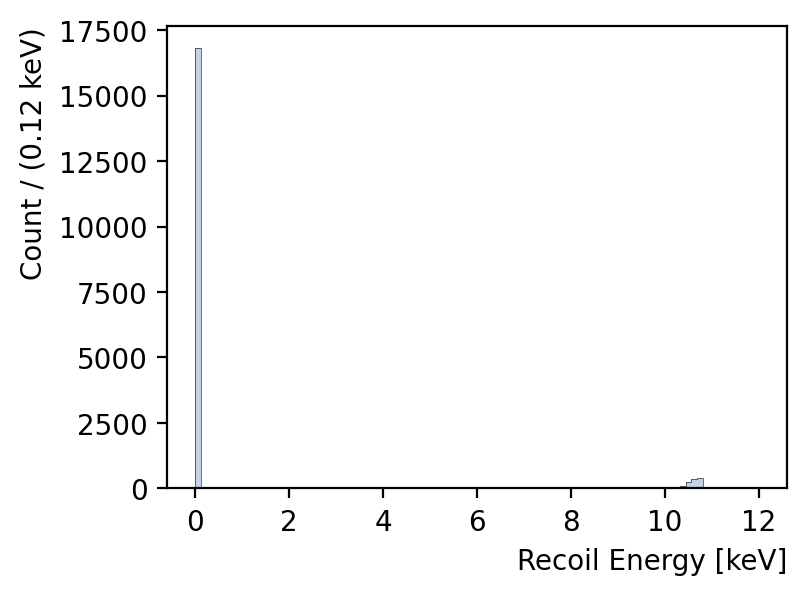

In [9]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Recoil Energy [keV]')
plt.ylabel('Count / (0.12 keV)')

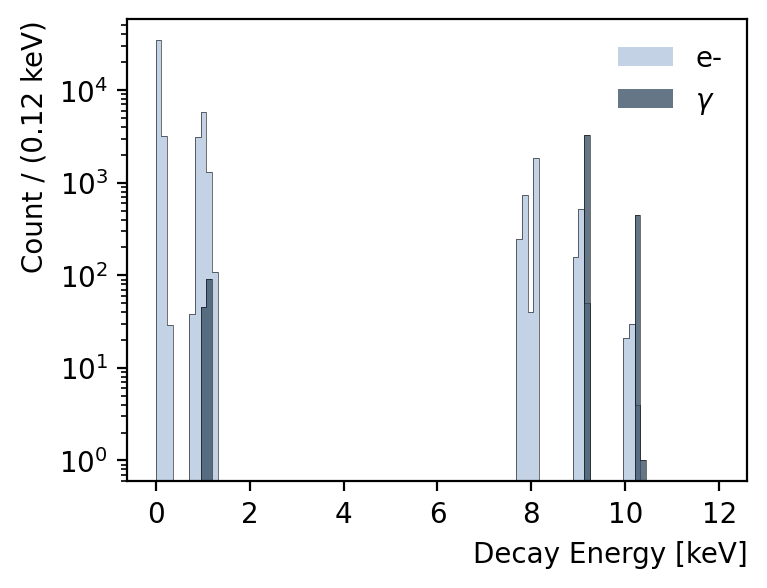

In [11]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 0, label = 'e-', color = 'C0')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'e-']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 1)
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75, zorder = 2, label = r'$\gamma$', color = 'C1')
plt.hist(mcDecays['KE'][mcDecays['PName'] == 'gamma']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, zorder = 3)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.yscale('log')
plt.legend()

Text(0, 1, 'Count / (0.12 keV)')

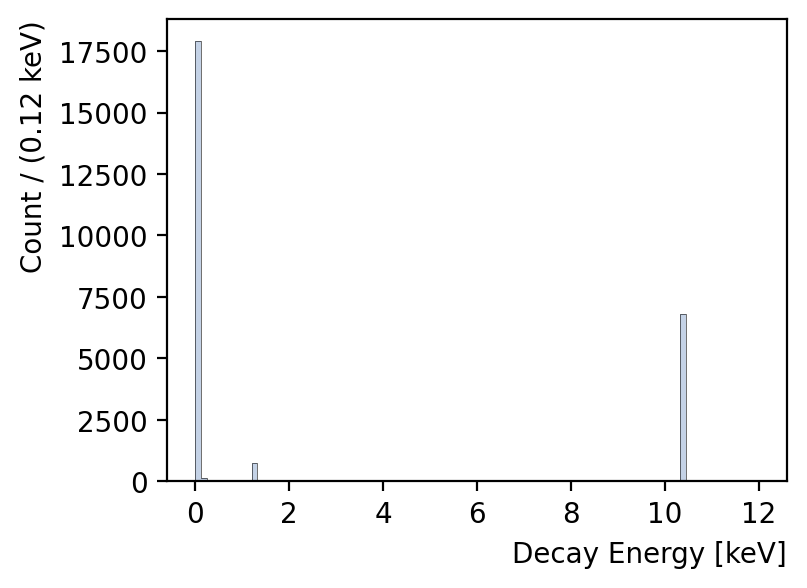

In [12]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), alpha = 0.75)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2)

plt.xlabel('Decay Energy [keV]')
plt.ylabel('Count / (0.12 keV)')

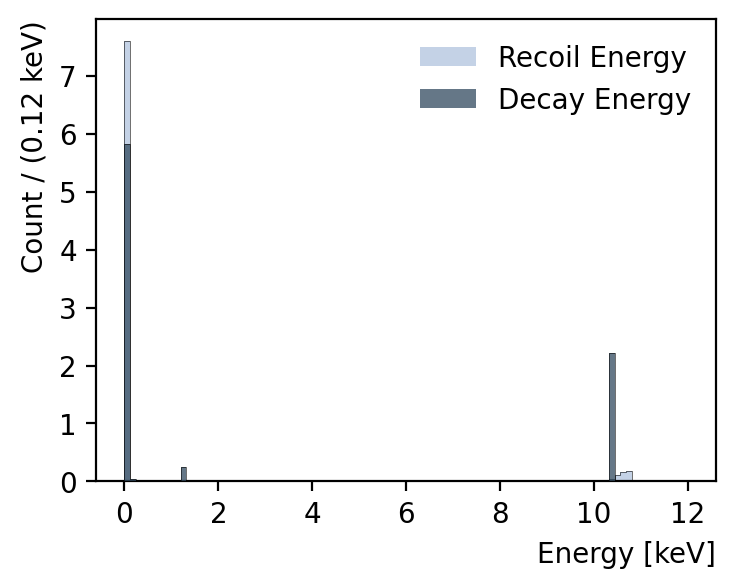

In [13]:
plt.figure(figsize=(4,3), dpi=200)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), density=True, label = 'Recoil Energy', color = 'C0', zorder = 1, alpha = 0.75)
plt.hist(mczip['Edepsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, density=True, zorder = 2)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), density=True, label = 'Decay Energy', color = 'C1', zorder = 3, alpha = 0.75)
plt.hist(mcDecays['KEsum']*1e-3, bins = np.linspace(0, 12, 101), histtype='step', color = 'black', lw = 0.2, density=True, zorder = 4)

plt.xlabel('Energy [keV]')
plt.ylabel('Count / (0.12 keV)')
plt.legend()